In [2]:
%load_ext autoreload
%autoreload 2

from IPython.display import Math, Latex

import pandas as pd, cvxpy as cp, numpy as np, matplotlib as mpl  # type: ignore
import matplotlib.pyplot as plt  # type: ignore

from matplotlib.ticker import FuncFormatter, MultipleLocator  # type: ignore
from matplotlib.patches import FancyArrowPatch, Polygon  # type: ignore
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

from scipy.integrate import quad  # type: ignore
from scipy.spatial import ConvexHull
from scipy.interpolate import interp1d

import importlib, itertools, csv, concurrent.futures
import os, math, sys, json, pickle, shutil, time, functools

from typing import Dict, List, Any, Optional, Literal
from tqdm.notebook import tqdm
import networkx as nx

from Utils import Notebook, tex, gph, sgn, nm, ds
from optimization import DisturbedSaturatedPETC as DSPETC

cfg = {
    'style': {'color': 'black'},
    'axis': {
        'title_pad': 10,
        'x_label_fontsize': 16,
        'y_label_fontsize': 16,
        'tick_fontsize': 16,
    },
    'legend': {'fontsize': 16}
}

colors_list = plt.get_cmap('tab20').colors
Notebook.setup()

LaTeX has been enabled for text rendering.


### Definição da Planta

In [3]:
experiment_filename = 'exp-03'

with open(f"experiment-datas/{experiment_filename}.json", encoding='utf-8') as f:
  exp_data = json.load(f)

plant = ds.StateSpace(data=exp_data["plant"], name='plant')
latex_expr = plant.get_latex_equations()
print("Equações que regem a dinâmica da planta:")
tex.display_latex(latex_expr)

Equações que regem a dinâmica da planta:


<IPython.core.display.Latex object>

### Projeto do Controlador e do ETM

In [4]:
import matplotlib.pyplot as plt

# Parâmetros
EXPERIMENT_FILE = f"experiment-datas/{experiment_filename}.json"

In [5]:
def run_problem_solving(
    h: float,
    υ: float,
    α: float,
    eps: float = 1e-6,
):
  n_x = plant.nx
  n_u = plant.nu

  Onx = np.zeros((n_x, n_x))

  matrices = plant.evaluate_matrices(None, None, None)
  A = matrices['A']
  B = matrices['B']

  e = nm.get_e(5 * [n_x])

  for i in range(1, len(e)):
    e[i] = cp.Parameter(e[i].shape, value=e[i], name=f"e{i}")

  constraints = []

  Ptil = cp.Variable((n_x, n_x), PSD=True)
  Mtil = cp.Variable((2 * n_x, 2 * n_x), PSD=True)
  Q1til = cp.Variable((n_x, n_x), symmetric=True)
  Q2til = cp.Variable((n_x, n_x))
  Q3til = cp.Variable((n_x, n_x))
  S1til = cp.Variable((n_x, n_x), symmetric=True)
  S2til = cp.Variable((n_x, n_x))
  S3til = cp.Variable((n_x, n_x))
  Ktil = cp.Variable((n_u, n_x))

  Rtil = cp.Variable((n_x, n_x), PSD=True)
  Ξtil = cp.Variable((n_x, n_x), PSD=True)
  Ψtil = cp.Variable((n_x, n_x), PSD=True)

  X = cp.Variable((n_x, n_x))
  Ytil = cp.Variable((2 * n_x, e[1].shape[1]))

  Rcal = cp.bmat([[Rtil, Onx],
                  [Onx, 3. * Rtil]])

  Fscr = e[1].T + υ * e[2].T + υ * e[4].T

  κ1 = cp.bmat([[e[2]], [e[5]]])
  κ2 = cp.bmat([[e[1] - e[2]],
                [e[1] + e[2] - 2. * e[3]]])

  def get_Θ(ω):
    Bscr = A @ X @ e[1] + B @ Ktil @ e[2] + \
        B @ Ktil @ e[5] - X @ e[4]
    Θ1 = (e[1] - e[2]).T @ S1til @ (e[1] - e[2]) + \
        nm.He((e[1] - e[2]).T @ (S2til @ e[2] + S3til @ e[5]))
    Θ2 = nm.He(e[3].T @ (Q2til @ e[2] + Q3til @ e[5]))
    Θ3 = nm.He(e[1].T @ (Q1til @ e[3] + Q2til @ e[2] + Q3til @ e[5]))
    Θ4 = nm.He(e[4].T @ (S1til @ (e[1] - e[2]) + S2til @
               e[2] + S3til @ e[5])) + e[4].T @ Rtil @ e[4]
    return nm.He(e[1].T @ Ptil @ e[4] + Fscr @ Bscr - κ2.T @ Ytil) - e[5].T @ Ξtil @ e[5] - \
        Θ1 - ω * Θ2 - h * e[3].T @ Q1til @ e[3] + \
        (h - ω) * Θ3 + (h - 2.0 * ω) * κ1.T @ Mtil @ κ1 + \
        (h - ω) * Θ4

  def get_Γ():
    Γ1_11 = get_Θ(0)
    Γ1_12 = e[2].T @ X.T
    Γ1_21 = Γ1_12.T
    Γ1_22 = - Ψtil

    Γ1 = cp.bmat([[Γ1_11, Γ1_12],
                  [Γ1_21, Γ1_22]])

    Γ2_11 = get_Θ(h)
    Γ2_12 = Ytil.T
    Γ2_21 = Γ2_12.T
    Γ2_22 = - (1. / h) * Rcal
    Γ2_13 = e[2].T @ X.T
    Γ2_23 = np.zeros((2 * n_x, n_x))
    Γ2_31 = Γ2_13.T
    Γ2_32 = Γ2_23.T
    Γ2_33 = - Ψtil

    Γ2 = cp.bmat([[Γ2_11, Γ2_12, Γ2_13],
                  [Γ2_21, Γ2_22, Γ2_23],
                  [Γ2_31, Γ2_32, Γ2_33]])

    return Γ1, Γ2

  Γ1, Γ2 = get_Γ()
  constraints += [Γ1 << -eps * np.eye(Γ1.shape[0])]
  constraints += [Γ2 << -eps * np.eye(Γ2.shape[0])]

  constraints += [Ξtil >> eps * np.eye(n_x)]
  constraints += [Ψtil >> eps * np.eye(n_x)]

  obj = cp.Minimize(cp.trace(α * Ξtil + (1.0 - α) * Ψtil))
  # obj = cp.Minimize(cp.trace(Ξtil + Ψtil))
  prob = cp.Problem(obj, constraints)

  try:
    prob.solve(solver=cp.MOSEK, verbose=False, ignore_dpp=True)
    if prob.status in ["infeasible", "unbounded"]:
      return None
    Xinv = np.linalg.inv(X.value)
    Ξ = Xinv.T @ Ξtil.value @ Xinv
    Ψ = np.linalg.inv(Ψtil.value)
    K = Ktil.value @ Xinv

    return {
        'etm': {'Ξ': Ξ, 'Ψ': Ψ},
        'controller': {'K': K},
        'status': prob.status,
        'obj_value': prob.value
    }

  except cp.error.SolverError:
    return None

In [6]:
A = plant.evaluate_matrices(None, None, None)['A']
B = plant.evaluate_matrices(None, None, None)['B']

h = exp_data["design_params"]['h']
iet_max = exp_data["design_params"]['iet_max']
υ = 1e-3
α = 0.5
results = run_problem_solving(h=h, υ=υ, α=α)

Ξ = results['etm']['Ξ']
Ψ = results['etm']['Ψ']
K = results['controller']['K']

# Verificação dos resultados
if results:
  print("=== Síntese Concluída com Sucesso ===")
  print(f"Status do Solver: {results['status']}")
  print(f"Valor da Função de Custo: {results['obj_value']:.4f}")

  print("\nGanho K:")
  print(results['controller']['K'])

  print("\nMatriz Xi (ETM):")
  print(results['etm']['Ξ'])

  print("\nMatriz Psi (ETM):")
  print(results['etm']['Ψ'])

else:
  print("!!! O problema restou Inviável para estes parâmetros !!!")

=== Síntese Concluída com Sucesso ===
Status do Solver: optimal
Valor da Função de Custo: 0.0056

Ganho K:
[[ 0.16496174 -1.4326743 ]]

Matriz Xi (ETM):
[[  21.86253048 -160.17161449]
 [-160.17161449 1392.62430773]]

Matriz Psi (ETM):
[[330.46700158  19.82698819]
 [ 19.82698819 433.33767143]]


### Experimento: Estimador das Matrizes do Sistema

In [7]:
class ContinuousMetrics:
  def __init__(self, eps=1e-9):
    self.eps = eps
    self.time = []
    self.residual = []
    self.stealthiness = []
    self.degradation = []

  def update(self, t, x_attack, x_nominal, y_attack, y_nominal):
    r = y_attack - y_nominal
    R = np.linalg.norm(r)
    S = 1.0 / (1.0 + R)
    D = np.linalg.norm(x_attack - x_nominal) / \
        (np.linalg.norm(x_nominal) + self.eps)

    self.time.append(t)
    self.residual.append(R)
    self.stealthiness.append(S)
    self.degradation.append(D)

  def arrays(self):
    return {
        "time": np.array(self.time),
        "residual": np.array(self.residual),
        "stealthiness": np.array(self.stealthiness),
        "degradation": np.array(self.degradation)
    }

In [8]:
import numpy as np

from scipy.linalg import expm
from scipy.optimize import least_squares
from scipy.linalg import pinv


# ==============================================================================
# ESTIMADOR CONTÍNUO APERIÓDICO PETC
# ==============================================================================


class AperiodicMatrixEstimator:

  def __init__(self, nx, nu):

    self.nx = nx
    self.nu = nu

    self.A_est = None
    self.B_est = None

    self.history = {

        "x_k": [],
        "u_k": [],
        "x_next": [],
        "tau_k": []

    }

  def record_transition(
          self,
          x_k,
          u_k,
          x_next,
          tau_k):
    """
    Store one PETC transmission interval.
    """

    self.history["x_k"].append(
        x_k.flatten()
    )

    self.history["u_k"].append(
        u_k.flatten()
    )

    self.history["x_next"].append(
        x_next.flatten()
    )

    self.history["tau_k"].append(
        tau_k
    )

  # ==========================================================================
  # Diagnóstico da informação dos dados
  # ==========================================================================

  def check_regressor_rank(self):
    """
    Check rank and conditioning of the identification data.

    The regressor is:

        [x(k)]
        [u(k)]
    """

    H = []

    for i in range(len(self.history["tau_k"])):

      x = np.array(
          self.history["x_k"][i]
      ).reshape(
          self.nx, 1
      )

      u = np.array(
          self.history["u_k"][i]
      ).reshape(
          self.nu, 1
      )

      H.append(
          np.vstack(
              [
                  x,
                  u
              ]
          ).flatten()
      )

    H = np.array(H).T

    rank = np.linalg.matrix_rank(H)

    cond = np.linalg.cond(H)

    print("\n===================================")
    print("DIAGNÓSTICO DO REGRESSOR")
    print("===================================")

    print(
        f"Posto(H): {rank}/{self.nx+self.nu}"
    )

    print(
        f"Condicionamento(H): {cond:.4e}"
    )

    print("===================================\n")

    return rank, cond

  # ==========================================================================
  # Estimação inicial para fornecer chute ao otimizador
  # ==========================================================================

  def initial_estimate(self):

    Y = []

    H = []

    for i in range(len(self.history["tau_k"])):

      tau = self.history["tau_k"][i]

      x = np.array(
          self.history["x_k"][i]
      ).reshape(
          self.nx, 1
      )

      u = np.array(
          self.history["u_k"][i]
      ).reshape(
          self.nu, 1
      )

      xn = np.array(
          self.history["x_next"][i]
      ).reshape(
          self.nx, 1
      )

      Y.append(
          ((xn-x)/tau).flatten()
      )

      H.append(
          np.vstack(
              [
                  x,
                  u
              ]
          ).flatten()
      )

    Y = np.array(Y).T

    H = np.array(H).T

    Theta = Y @ pinv(H)

    A0 = Theta[:, :self.nx]

    B0 = Theta[:, self.nx:]

    return A0, B0

  # ==========================================================================
  # Dinâmica discreta exata
  # ==========================================================================

  def discrete_model(
          self,
          A,
          B,
          tau):

    M = np.zeros(
        (
            self.nx+self.nu,
            self.nx+self.nu
        )
    )

    M[:self.nx, :self.nx] = A

    M[:self.nx, self.nx:] = B

    Md = expm(
        M*tau
    )

    Phi = Md[:self.nx, :self.nx]

    Gamma = Md[:self.nx, self.nx:]

    return Phi, Gamma

  # ==========================================================================
  # Otimização usando todos os eventos
  # ==========================================================================

  def estimate_model(self):

    self.check_regressor_rank()

    A0, B0 = self.initial_estimate()

    theta0 = np.concatenate(
        [
            A0.flatten(),
            B0.flatten()
        ]
    )

    X = [
        np.array(x).reshape(self.nx, 1)
        for x in self.history["x_k"]
    ]

    U = [
        np.array(u).reshape(self.nu, 1)
        for u in self.history["u_k"]
    ]

    XN = [
        np.array(x).reshape(self.nx, 1)
        for x in self.history["x_next"]
    ]

    TAU = np.array(
        self.history["tau_k"]
    )

    def residual(theta):

      A = theta[:self.nx*self.nx].reshape(
          self.nx, self.nx
      )

      B = theta[self.nx*self.nx:].reshape(
          self.nx, self.nu
      )

      errors = []

      for i in range(len(TAU)):

        Phi, Gamma = self.discrete_model(
            A,
            B,
            TAU[i]
        )

        pred = (
            Phi @ X[i]
            +
            Gamma @ U[i]
        )

        errors.extend(
            (XN[i]-pred).flatten()
        )

      return np.array(errors)

    result = least_squares(
        residual,
        theta0,
        method="trf"
    )

    theta = result.x

    self.A_est = theta[:self.nx*self.nx].reshape(
        self.nx, self.nx
    )

    self.B_est = theta[self.nx*self.nx:].reshape(
        self.nx, self.nu
    )

    print(
        "Otimização concluída:"
    )

    print(
        "Custo final:",
        np.linalg.norm(result.fun)
    )

    return self.A_est, self.B_est

  # ==========================================================================
  # Validação
  # ==========================================================================

  def compute_validation_metrics(
          self,
          A_true,
          B_true):

    err_A = (
        np.linalg.norm(
            self.A_est-A_true
        )
        /
        np.linalg.norm(A_true)
    )

    err_B = (
        np.linalg.norm(
            self.B_est-B_true
        )
        /
        np.linalg.norm(B_true)
    )

    errors = []

    for i in range(
        len(self.history["tau_k"])
    ):

      tau = self.history["tau_k"][i]

      x = np.array(
          self.history["x_k"][i]
      ).reshape(self.nx, 1)

      u = np.array(
          self.history["u_k"][i]
      ).reshape(self.nu, 1)

      xn = np.array(
          self.history["x_next"][i]
      ).reshape(self.nx, 1)

      Phi, Gamma = self.discrete_model(
          self.A_est,
          self.B_est,
          tau
      )

      xp = Phi@x+Gamma@u

      errors.append(
          np.linalg.norm(
              xn-xp
          )
      )

    return {

        "norm_error_A": err_A,

        "norm_error_B": err_B,

        "mean_prediction_error":
            np.mean(errors),

        "max_prediction_error":
            np.max(errors)

    }
# ==============================================================================
# MÓDULO 2: AMBIENTE PETC NOMINAL
# ==============================================================================


plant_data = exp_data["plant"]

plant_attack = ds.StateSpace(
    data=plant_data,
    name="nominal"
)
mat = plant_attack.evaluate_matrices()

A_true = mat["A"]
B_true = mat["B"]
C_true = mat["C"]


plant_nominal = ds.StateSpace(
    data=plant_data,
    name="nominal"
)


sim = ds.SimulationEngineOld()

sim.add_system(
    plant_nominal
)


nx, nu = B_true.shape


K = results["controller"]["K"]


Xi = results["etm"]["Ξ"]

Psi = results["etm"]["Ψ"]


h = exp_data["design_params"]["h"]


sampler = ds.Sampler(
    Ts=h,
    time_source=lambda: sim.t
)


setm_nominal = DSPETC.SETM(
    Ξ=Xi,
    Ψ=Psi
)


sim.add_system(
    setm_nominal
)


# ==============================================================================
# Inicialização
# ==============================================================================


x0 = np.array(
    [
        [1.0],
        [-1.0]
    ],
    dtype=np.float32
)


plant_nominal.set_initial_state(
    x0
)


setm_nominal.x_hat = x0.copy()

setm_nominal.xm = x0.copy()


uc_n = K @ x0


estimator = AperiodicMatrixEstimator(
    nx,
    nu
)


event_timestamps = [0.0]


x_at_last_event = x0.copy()

u_at_last_event = uc_n.copy()


sim.setup_clock(
    duration=15.0,
    dt=1e-4
)


sim.reset_clock()

sampler.reset()


# ==============================================================================
# Simulação PETC + captura
# ==============================================================================


while sim.advance_clock():

  # Controle mantido durante o intervalo
  u_interval = uc_n.copy()

  with sim.step(
      default_inputs={
          "nominal":
          {
              "u1": u_interval.reshape(-1, 1)
          }
      }
  ):

    xn = (
        plant_nominal.states.copy()
        .reshape(nx, 1)
    )

  if sampler.check():

    setm_nominal.xm = xn.copy()

    if setm_nominal.triggering_condition():

      t_current = sim.t

      tau_k = (
          t_current
          -
          event_timestamps[-1]
      )

      estimator.record_transition(

          x_k=x_at_last_event,

          u_k=u_interval,

          x_next=xn,

          tau_k=tau_k
      )

      event_timestamps.append(
          t_current
      )

      x_at_last_event = xn.copy()

      setm_nominal.x_hat = xn.copy()

      uc_n = (
          K @ setm_nominal.x_hat
      )


# ==============================================================================
# Estimação
# ==============================================================================


print(
    "Janela PETC concluída."
)


print(
    f"Eventos capturados: {len(event_timestamps)}"
)


A_est, B_est = estimator.estimate_model()


validation = estimator.compute_validation_metrics(
    A_true,
    B_true
)


print("\n====================================================")

print(
    "             RELATÓRIO DE ESTIMAÇÃO"
)

print("====================================================")


print(
    f"Erro relativo da norma de A: "
    f"{validation['norm_error_A']:.6e}"
)


print(
    f"Erro relativo da norma de B: "
    f"{validation['norm_error_B']:.6e}"
)


print(
    f"Erro médio de predição: "
    f"{validation['mean_prediction_error']:.6e}"
)


print(
    f"Erro máximo de predição: "
    f"{validation['max_prediction_error']:.6e}"
)


print("====================================================")

Janela PETC concluída.
Eventos capturados: 44

DIAGNÓSTICO DO REGRESSOR
Posto(H): 2/3
Condicionamento(H): 4.7360e+15

Otimização concluída:
Custo final: 4.866514064677767e-05

             RELATÓRIO DE ESTIMAÇÃO
Erro relativo da norma de A: 1.719516e-04
Erro relativo da norma de B: 2.868285e-04
Erro médio de predição: 3.747503e-06
Erro máximo de predição: 2.977651e-05


In [9]:
taus = np.array(estimator.history["tau_k"])

print("Tau mínimo:", taus.min())
print("Tau máximo:", taus.max())
print("Tau distintos:",
      len(np.unique(np.round(taus, 6))))

Tau mínimo: 0.14999986
Tau máximo: 1.1
Tau distintos: 21


In [10]:
print(A_est)

[[ 8.72671185e-05  9.99661587e-01]
 [-4.00062019e+00  4.00024462e-01]]


### Ataque de Dinâmica Zero

In [11]:
import numpy as np
from scipy.linalg import null_space, expm


class SwitchedZeroDynamicsAttack:
  def __init__(self, nx, nu, ny):
    self.nx = nx
    self.nu = nu
    self.ny = ny
    self.active = False
    self.k = 0

    # Matrizes contínuas aprendidas pelo estimador black-box
    self.A_hat = None
    self.B_hat = None

    # Direções dinâmicas invariantes no tempo contínuo, adaptadas na discretização
    self.z_state = np.zeros((nx, 1))
    self.a_input = np.zeros((nu, 1))

    # Histórico completo do atacante para auditoria do artigo
    self.attack_history = {
        "nu_k": [],         # Evolução temporal do polo de ataque variante
        "a_additive": [],   # Sinal injetado nos atuadores
        "x_makeup": []      # Vetor de maquiagem subtraído do sensor
    }

  def activate_attack(self, A_estimated, B_estimated):
    """Bloqueia o modelo contínuo identificado e inicializa o estado do ataque."""
    self.A_hat = A_estimated.copy()
    self.B_hat = B_estimated.copy()
    self.active = True
    self.k = 0
    # Estado interno inicial do gerador do ataque (condição inicial da dinâmica zero virtual)
    self.z_state = np.ones((self.nx, 1)) * 0.1

  def compute_switched_injection(self, tau_k):
    """
    Calcula a matriz de Rosenbrock discreta instantânea para o intervalo tau_k
    corrente e extrai as direções nulas comutadas (Wolleswinkel et al.).
    """
    if not self.active:
      return np.zeros((self.nu, 1)), np.zeros((self.nx, 1))

    # 1. Discretização exata instantânea baseada no tau_k atual da rede
    M = np.zeros((self.nx + self.nu, self.nx + self.nu))
    M[:self.nx, :self.nx] = self.A_hat
    M[:self.nx, self.nx:] = self.B_hat
    Md = expm(M * tau_k)

    Phi_k = Md[:self.nx, :self.nx]
    Gamma_k = Md[:self.nx, self.nx:]

    # 2. Localização do polo instável discreto equivalente para este passo
    eigs = np.linalg.eigvals(Phi_k)
    # Seleciona o maior autovalor instável induzido pelo ZOH
    nu_k = np.real(eigs[np.argmax(np.abs(eigs))])
    if nu_k < 1.05:
      nu_k = 1.1  # Fallback de crescimento geométrico mínimo

    # 3. Construção da Matriz de Rosenbrock Comutada (C = Identity)
    C_identity = np.eye(self.nx)
    Rosen_k = np.block([
        [nu_k * np.eye(self.nx) - Phi_k, -Gamma_k],
        [C_identity,                      np.zeros((self.ny, self.nu))]
    ])

    # 4. Solução do núcleo para garantir o resíduo nulo nos instantes de amostragem
    ker = null_space(Rosen_k)
    if ker.shape[1] > 0:
      v = ker[:, 0]
      x0_k = v[:self.nx].reshape(self.nx, 1)
      g_k = v[self.nx:].reshape(self.nu, 1)
    else:
      x0_k = np.ones((self.nx, 1)) * 0.05
      g_k = np.ones((self.nu, 1)) * 0.05

    # Normalização de amplitude para controle estatístico do stress
    if np.linalg.norm(g_k) > 0:
      g_k /= np.linalg.norm(g_k)

    # 5. Evolução da equação de estados do atacante chaveada
    self.a_input = g_k * (nu_k ** self.k)
    x_makeup = x0_k * (nu_k ** self.k)

    # Atualiza registros de auditoria
    self.attack_history["nu_k"].append(nu_k)
    self.attack_history["a_additive"].append(self.a_input.flatten())
    self.attack_history["x_makeup"].append(x_makeup.flatten())

    self.k += 1
    return self.a_input, x_makeup

In [41]:
from scipy.linalg import expm, pinv
from scipy.linalg import expm, pinv, null_space
import numpy as np
from scipy.linalg import expm
from scipy.optimize import least_squares


# ==============================================================================
# ESTIMADOR BLACK-BOX DO ADVERSÁRIO
# ==============================================================================


class AperiodicMatrixEstimator:

  def __init__(self, nx, nu):

    self.nx = nx
    self.nu = nu

    self.A_est = None
    self.B_est = None

    self.cost = None

    self.history = {
        "x_k": [],
        "u_k": [],
        "x_next": [],
        "tau_k": []
    }

  def record_transition(
          self,
          x_k,
          u_k,
          x_next,
          tau_k):

    if tau_k <= 1e-10:
      return

    self.history["x_k"].append(
        x_k.flatten()
    )

    self.history["u_k"].append(
        u_k.flatten()
    )

    self.history["x_next"].append(
        x_next.flatten()
    )

    self.history["tau_k"].append(
        tau_k
    )

  def discrete_model(self, A, B, tau):

    M = np.zeros(
        (
            self.nx+self.nu,
            self.nx+self.nu
        )
    )

    M[:self.nx, :self.nx] = A
    M[:self.nx, self.nx:] = B

    Md = expm(M*tau)

    Phi = Md[:self.nx, :self.nx]
    Gamma = Md[:self.nx, self.nx:]

    return Phi, Gamma

  def initial_guess(self):

    Y = []
    H = []

    for x, u, xn, tau in zip(
        self.history["x_k"],
        self.history["u_k"],
        self.history["x_next"],
        self.history["tau_k"]
    ):

      x = x.reshape(self.nx, 1)
      u = u.reshape(self.nu, 1)
      xn = xn.reshape(self.nx, 1)

      Y.append(
          ((xn-x)/tau).flatten()
      )

      H.append(
          np.vstack(
              [
                  x,
                  u
              ]
          ).flatten()
      )

    Y = np.array(Y).T
    H = np.array(H).T

    Theta = Y @ np.linalg.pinv(H)

    return (
        Theta[:, :self.nx],
        Theta[:, self.nx:]
    )

  def check_data_quality(self):

    H = []

    for x, u in zip(
        self.history["x_k"],
        self.history["u_k"]
    ):

      H.append(
          np.concatenate(
              [x, u]
          )
      )

    H = np.array(H).T

    rank = np.linalg.matrix_rank(H)
    cond = np.linalg.cond(H)

    # print("\nREGRESSOR")
    # print("----------------")
    # print(
    #     f"rank = {rank}/{self.nx+self.nu}"
    # )
    # print(
    #     f"cond = {cond:.3e}"
    # )

    return rank, cond

  def estimate_model(self):

    self.check_data_quality()

    A0, B0 = self.initial_guess()

    theta0 = np.concatenate(
        [
            A0.flatten(),
            B0.flatten()
        ]
    )

    X = [
        x.reshape(self.nx, 1)
        for x in self.history["x_k"]
    ]

    U = [
        u.reshape(self.nu, 1)
        for u in self.history["u_k"]
    ]

    XN = [
        x.reshape(self.nx, 1)
        for x in self.history["x_next"]
    ]

    TAU = np.array(
        self.history["tau_k"]
    )

    def residual(theta):

      A = theta[:self.nx*self.nx].reshape(
          self.nx, self.nx
      )

      B = theta[self.nx*self.nx:].reshape(
          self.nx, self.nu
      )

      err = []

      for i, tau in enumerate(TAU):

        Phi, Gamma = self.discrete_model(
            A, B, tau
        )

        xp = (
            Phi@X[i]
            +
            Gamma@U[i]
        )

        err.extend(
            (XN[i]-xp).flatten()
        )

      return np.array(err)

    sol = least_squares(
        residual,
        theta0
    )

    self.cost = np.linalg.norm(
        sol.fun
    )

    theta = sol.x

    self.A_est = theta[:self.nx*self.nx].reshape(
        self.nx, self.nx
    )

    self.B_est = theta[self.nx*self.nx:].reshape(
        self.nx, self.nu
    )

    return (
        self.A_est,
        self.B_est,
        self.cost
    )


# ==============================================================================
# DETECTOR DO PROJETISTA
# ==============================================================================


class ResidualAttackDetector:
  def __init__(self, A, B, threshold):
    self.A = A
    self.B = B
    self.threshold = threshold
    self.x_hat = None
    self.is_under_attack = False

  def initialize(self, x0):
    self.x_hat = x0.copy()

  def predict(self, u, tau):
    M = np.zeros((self.A.shape[0] + self.B.shape[1],
                 self.A.shape[0] + self.B.shape[1]))
    n = self.A.shape[0]
    M[:n, :n] = self.A
    M[:n, n:] = self.B

    Md = expm(M * tau)
    Phi = Md[:n, :n]
    Gamma = Md[:n, n:]
    return Phi @ self.x_hat + Gamma @ u

  def process(self, x_network, xa_actual, u, tau):
    """
    x_network: O dado corrompido que chegou pela rede (xa - x_makeup).
    xa_actual: O dado analógico original direto da planta física (Canal Seguro).
    """
    # A predição do resíduo sempre assume o que deveria ter chegado nominalmente
    x_pred = self.predict(u, tau)

    # O cálculo do resíduo avalia o descompasso do dado da rede
    residual = np.linalg.norm(x_network - x_pred)

    if residual > self.threshold:
      self.is_under_attack = True

    if self.is_under_attack:
      # ABSTRAÇÃO DO CANAL SEGURO:
      # Em vez de usar um modelo preditivo para corrigir (que acumularia erros),
      # o sistema chaveia para o link redundante e captura o dado original purificado 'xa_actual'.
      self.x_hat = xa_actual.copy()
      return xa_actual, True

    # Caso contrário, o sistema opera normalmente atualizando-se com o dado da rede
    self.x_hat = x_network.copy()
    return x_network, False


class SwitchedZeroDynamicsAttack:
  def __init__(self, nx, nu, K_gain, ny, alpha=1.9):
    self.nx = nx
    self.nu = nu
    self.ny = ny
    self.alpha = alpha

    self.K = np.atleast_2d(K_gain)
    if self.K.shape[0] != nu or self.K.shape[1] != nx:
      if self.K.shape[0] == nx and self.K.shape[1] == nu:
        self.K = self.K.T
      else:
        raise ValueError("Dimensões de K incompatíveis.")

    self.active = False
    self.A_hat = None
    self.B_hat = None
    self.attack_history = {"nu_k": [], "a_additive": [], "x_makeup": []}

  def discrete_model(self, A, B, tau):
    M = np.zeros((self.nx + self.nu, self.nx + self.nu))
    M[:self.nx, :self.nx] = A
    M[:self.nx, self.nx:] = B
    Md = expm(M * tau)
    return Md[:self.nx, :self.nx], Md[:self.nx, self.nx:]

  def activate_attack(self, A_estimated, B_estimated):
    self.A_hat = A_estimated.copy()
    self.B_hat = B_estimated.copy()
    self.active = True

  def compute_switched_injection(self, tau_k, xa_actual):
    if not self.active:
      return np.zeros((self.nu, 1)), np.zeros((self.nx, 1))

    # 1. Obter matrizes discretas (Phi, Gamma) para o tau_k atual
    Phi_k, Gamma_k = self.discrete_model(self.A_hat, self.B_hat, tau_k)

    # 2. Formulação do ataque:
    # O sistema sob ataque deve evoluir como x_{k+1} = alpha * x_k
    # Equação: Gamma * a_k = (alpha * I - Phi) * x_k - Gamma * K * x_k

    target_dynamics = (self.alpha * np.eye(self.nx) - Phi_k) @ xa_actual
    nominal_control = Gamma_k @ (self.K @ xa_actual)

    # 3. Cálculo da injeção usando pseudo-inversa (solução de mínima norma)
    Gamma_dag = pinv(Gamma_k)
    a_input = Gamma_dag @ (target_dynamics - nominal_control)

    # 4. Cálculo do sinal de maquiagem (x_makeup) para o controlador
    # O controlador espera que x_{k+1} = Phi * x_k + Gamma * K * x_makeup
    # O atacante projeta x_makeup para manter a furtividade relativa
    x_makeup = xa_actual - (xa_actual * (1.0 / self.alpha))

    self.attack_history["nu_k"].append(self.alpha)
    self.attack_history["a_additive"].append(a_input.flatten())
    self.attack_history["x_makeup"].append(x_makeup.flatten())

    return a_input, x_makeup


# ==============================================================================
# INFRAESTRUTURA DE SIMULAÇÃO APERIÓDICA (ETC REAL)
# ==============================================================================
plant_data = exp_data["plant"]
plant_attack = ds.StateSpace(data=plant_data, name="plant_attack")
plant_nominal = ds.StateSpace(data=plant_data, name="plant_nominal")
sim = ds.SimulationEngineOld()
sim.add_system(plant_attack)
sim.add_system(plant_nominal)

mat_matrices = plant_attack.evaluate_matrices()
A_true, B_true, C_true = mat_matrices["A"], mat_matrices["B"], mat_matrices["C"]
nx, nu = B_true.shape
ny = C_true.shape[0]

K = results["controller"]["K"]
Xi, Psi = results["etm"]["Ξ"], results["etm"]["Ψ"]
h = exp_data["design_params"]["h"]

sampler = ds.Sampler(Ts=h, time_source=lambda: sim.t)
setm_attack = DSPETC.SETM(Ξ=Xi, Ψ=Psi)
setm_nominal = DSPETC.SETM(Ξ=Xi, Ψ=Psi)
sim.add_system(setm_attack)
sim.add_system(setm_nominal)

x0 = np.array([[1.0], [-1.0]], dtype=np.float32)
plant_attack.set_initial_state(x0)
plant_nominal.set_initial_state(x0)
setm_attack.x_hat, setm_nominal.x_hat = x0.copy(), x0.copy()
setm_attack.xm, setm_nominal.xm = x0.copy(), x0.copy()

estimator = AperiodicMatrixEstimator(nx, nu)
attack_manager = SwitchedZeroDynamicsAttack(nx, nu, K, ny)
metrics = ContinuousMetrics()

uc_attack = K @ x0
uc_nominal = K @ x0
a_signal = np.zeros((nu, 1))
x_makeup_signal = np.zeros((nx, 1))

event_time_nominal, event_time_attack = [], []
timestamps_attack = [0.0]
x_last_event_attack = x0.copy()
u_last_interval_attack = uc_attack.copy()

# Parâmetros lógicos do experimento
error_threshold = 1e-3
max_learning_time = 60.0
attack_triggered = False

sim.setup_clock(duration=10.0, dt=1e-4)
sim.reset_clock()
sampler.reset()


# ==============================================================================
# PARAMETRIZAÇÃO GERAL DO EXPERIMENTO (CONTROLE DE CENÁRIO)
# ==============================================================================
has_attack = True          # TRUE: Ativa o SZDA | FALSE: Perfeito sincronismo nominal
error_threshold = 1e-3     # Limiar de custo para o adversário validar o modelo
detector_threshold = 0.15  # Limiar para o sistema de proteção por resíduo

# ==============================================================================
# INFRAESTRUTURA DE MATRIZES E ENGENHARIA DE SIMULAÇÃO
# ==============================================================================
plant_data = exp_data["plant"]
plant_attack = ds.StateSpace(data=plant_data, name="plant_attack")
plant_nominal = ds.StateSpace(data=plant_data, name="plant_nominal")

sim = ds.SimulationEngineOld()
sim.add_system(plant_attack)
sim.add_system(plant_nominal)

mat_matrices = plant_attack.evaluate_matrices()
A_true, B_true, C_true = mat_matrices["A"], mat_matrices["B"], mat_matrices["C"]
nx, nu = B_true.shape
ny = C_true.shape[0]

K = results["controller"]["K"]
Xi, Psi = results["etm"]["Ξ"], results["etm"]["Ψ"]
h = exp_data["design_params"]["h"]

sampler = ds.Sampler(Ts=h, time_source=lambda: sim.t)
setm_attack = DSPETC.SETM(Ξ=Xi, Ψ=Psi)
setm_nominal = DSPETC.SETM(Ξ=Xi, Ψ=Psi)
sim.add_system(setm_attack)
sim.add_system(setm_nominal)

# Condições iniciais limpas e idênticas para osHold
x0 = np.array([[1.0], [-1.0]], dtype=np.float32)
plant_attack.set_initial_state(x0)
plant_nominal.set_initial_state(x0)
setm_attack.x_hat, setm_nominal.x_hat = x0.copy(), x0.copy()
setm_attack.xm, setm_nominal.xm = x0.copy(), x0.copy()

# Instanciação única dos objetos periféricos de segurança
estimator = AperiodicMatrixEstimator(nx, nu)
attack_manager = SwitchedZeroDynamicsAttack(nx, nu, K, ny)
detector = ResidualAttackDetector(
    A=A_true, B=B_true, threshold=detector_threshold)
metrics = ContinuousMetrics()

detector.initialize(x0)

# Sinais de controle e atuadores discretos iniciais
uc_attack = K @ x0
uc_nominal = K @ x0
a_signal = np.zeros((nu, 1))
x_makeup_signal = np.zeros((nx, 1))

# Históricos de eventos e sincronismo temporal
event_time_nominal = []
event_time_attack = []
timestamps_attack = [0.0]

x_last_event_attack = x0.copy()
u_last_interval_attack = uc_attack.copy()

# Flags de fluxo do Adversário
attack_triggered = False
attack_learning_done = False
next_check_packet = 20

sim.setup_clock(duration=60.0, dt=1e-4)
sim.reset_clock()
sampler.reset()


# ==============================================================================
# LAÇO PRINCIPAL APERIÓDICO (ETC) - ARQUITETURA CORRIGIDA
# ==============================================================================

# Inicialização de buffers globais necessários
uc_attack = K @ x0
uc_nominal = K @ x0
a_signal = np.zeros((nu, 1))
x_makeup_signal = np.zeros((nx, 1))
event_time_nominal, event_time_attack = [], []
timestamps_attack = [0.0]
x_last_event_attack = x0.copy()
u_last_interval_attack = uc_attack.copy()
setm_attack.x_hat = x0.copy()

while sim.advance_clock():
    # A atuação física ocorre com o controle já calculado
    # Se o detector indica ataque, o atuador ignora a injeção do atacante (a_signal)
  if detector.is_under_attack:
    u_a_hold = uc_attack
  else:
    u_a_hold = uc_attack + (a_signal if has_attack else np.zeros((nu, 1)))

  with sim.step(default_inputs={
      "plant_nominal": {"u1": uc_nominal.reshape(-1, 1)},
      "plant_attack": {"u1": u_a_hold.reshape(-1, 1)}
  }):
    xn = plant_nominal.states.copy().reshape(nx, 1)
    xa = plant_attack.states.copy().reshape(nx, 1)
    metrics.update(sim.t, xa, xn, C_true @ xa, C_true @ xn)

  # Lógica de Amostragem
  if sampler.check():
    # --- 1. MALHA NOMINAL (Referência) ---
    setm_nominal.xm = xn.copy()
    if setm_nominal.triggering_condition() or sim.t == 0.0:
      setm_nominal.x_hat = xn.copy()
      uc_nominal = K @ setm_nominal.x_hat
      event_time_nominal.append(sim.t)

    # --- 2. MALHA SOB ATAQUE (Processamento no Controlador) ---
    tau_k = sim.t - timestamps_attack[-1]

    # A. Decisão do ETM (O gatilho dispara ou mantém o ZOH)
    if setm_attack.triggering_condition() or sim.t == 0.0:
      # Pacote é enviado pela rede e interceptado pelo atacante
      x_received = xa.copy() - (x_makeup_signal if has_attack and attack_triggered else 0)
    else:
      # Manutenção do valor retido (ZOH)
      x_received = setm_attack.x_hat.copy()

    # B. DETECÇÃO (O detector verifica o dado que chegou no controlador)
    # Processa o resíduo entre o que foi recebido e a predição local
    x_clean, detected = detector.process(
        x_received, xa, u_last_interval_attack, tau_k)

    # C. MITIGAÇÃO (Comutação do sinal do sensor)
    if detector.is_under_attack:
      setm_attack.xm = x_clean  # Canal Seguro
    else:
      setm_attack.xm = x_received  # Canal da Rede
    # setm_attack.xm = x_received  # Canal da Rede

    # D. ATUALIZAÇÃO DO CONTROLADOR (Lei de controle)
    if setm_attack.triggering_condition() or sim.t == 0.0:
      setm_attack.x_hat = setm_attack.xm.copy()
      uc_attack = K @ setm_attack.x_hat

      # --- FASE 1: APRENDIZADO ADVERSÁRIO (Passivo) ---
      if has_attack and not attack_triggered and not attack_learning_done:
        estimator.record_transition(
            x_last_event_attack, u_last_interval_attack, xa, tau_k)

        current_packets = len(estimator.history["tau_k"])
        if current_packets >= next_check_packet:
          try:
            A_hat, B_hat, cost = estimator.estimate_model()
            if cost < error_threshold:
              print(f"\n[SZDA] Ativado em t={sim.t:.2f}s | Custo: {cost:.4e}")
              attack_manager.activate_attack(A_hat, B_hat)
              attack_triggered = True
              attack_learning_done = True
            else:
              next_check_packet += 10
          except:
            next_check_packet += 5

      # --- FASE 2: EXECUÇÃO DO ATAQUE ---
      if has_attack and attack_triggered:
        a_signal, x_makeup_signal = attack_manager.compute_switched_injection(
            tau_k, xa)
      else:
        a_signal = np.zeros((nu, 1))
        x_makeup_signal = np.zeros((nx, 1))

      # Atualização dos buffers de rede
      timestamps_attack.append(sim.t)
      x_last_event_attack = xa.copy()
      u_last_interval_attack = uc_attack.copy()
      event_time_attack.append(sim.t)

  # Proteção de divergência numérica
  if np.linalg.norm(xa) > 1e6:
    print(f"Divergência detectada em t={sim.t:.2f}s")
    break

# ==============================================================================
# IMPRESSÃO DO DIAGNÓSTICO RETIFICADO
# ==============================================================================
print("\n====================================================")
print("             DIAGNÓSTICO FINAL DA REDE              ")
print("====================================================")
print(f"Injeção ativa (has_attack): {has_attack}")
print(f"O sinal do ataque chegou a ser disparado? {attack_triggered}")
print(f"O detector por resíduo foi sensibilizado? {detector.is_under_attack}")
print(
    f"Transmissões na Rede: Nominal = {len(event_time_nominal)} | Sob Teste = {len(event_time_attack)}")
print("====================================================")


[SZDA] Ativado em t=7.20s | Custo: 4.8597e-05

             DIAGNÓSTICO FINAL DA REDE              
Injeção ativa (has_attack): True
O sinal do ataque chegou a ser disparado? True
O detector por resíduo foi sensibilizado? True
Transmissões na Rede: Nominal = 185 | Sob Teste = 185


Dados processados: 600000 amostras válidas.


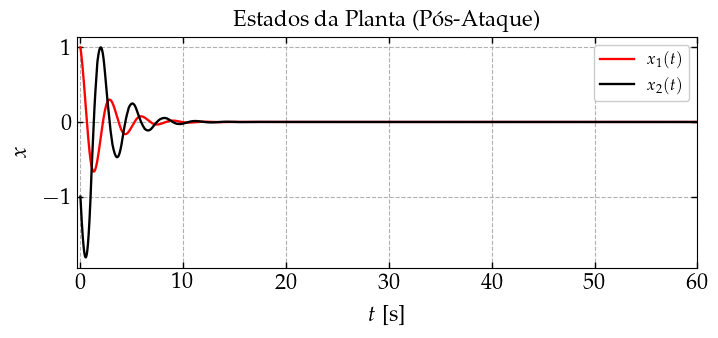

In [42]:
# 1. Filtra pares de (tempo, estado) válidos
# Isso remove qualquer passo da simulação onde o estado foi None
raw_history = sim.output_history['plant_attack']
valid_data = [(t, item) for t, item in zip(
    sim.time_history, raw_history) if item is not None]

# 2. Separa os dados limpos
# Extrai o tempo filtrado e converte os estados (nx, 1) para (N, nx)
times = np.array([x[0] for x in valid_data])
plant_data = np.array([x[1].flatten() for x in valid_data])

print(f"Dados processados: {plant_data.shape[0]} amostras válidas.")

# 3. Plotagem
x1_series = plant_data[:, 0]
x2_series = plant_data[:, 1]

_, axs = plt.subplot_mosaic([['x']], figsize=(8, 3))
_ = gph.plot(
    axs["x"],
    times,           # Usa o tempo filtrado e sincronizado
    [x1_series, x2_series],
    title="Estados da Planta (Pós-Ataque)",
    label=[r'$x_1(t)$', r'$x_2(t)$'],
    xlabel="$t$", x_unit='s', ylabel=fr'$x$',
    color=["red", "black"],
    x_use_prefixes=True, x_pad=(0.005, 0.0), y_pad=(0.05, 0.05)
)

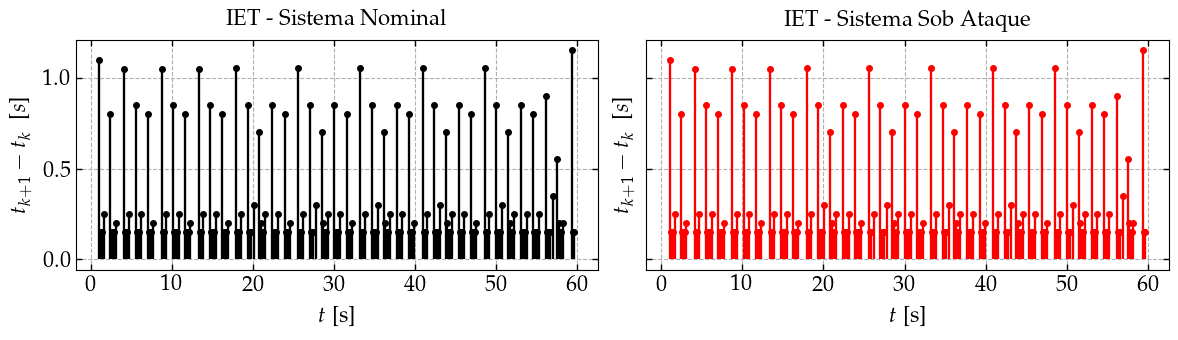

In [43]:
# Criando mosaico com dois subplots lado a lado ('nominal' e 'attack')
fig, axs = plt.subplot_mosaic(
    [['nominal', 'attack']], figsize=(12, 3.5), sharey=True)

# ------------------------------------------------------------------------------
# 1. GRAFICAR IET - CENÁRIO NOMINAL (Sem Ataque)
# ------------------------------------------------------------------------------
if len(event_time_nominal) > 1:
  iet_nominal = DSPETC.get_iet(np.array(event_time_nominal[1:]))

  _ = gph.stem(
      axs['nominal'], event_time_nominal[1:], iet_nominal, y_pad=(0.0, 0.05), x_use_prefixes=True,
      title="IET - Sistema Nominal",
      xlabel='$t$', x_unit='s', x_range=(0.0, sim.time_history[-1]),
      ylabel='$t_{k+1} - t_k\\;$ [$s$]',
      cfg={**cfg, 'limits': {'x_min': 0, 'x_max': sim.time_history[-1]},
           'style': {'color': "black"}}
  )

# ------------------------------------------------------------------------------
# 2. GRAFICAR IET - CENÁRIO SOB ATAQUE
# ------------------------------------------------------------------------------
if len(event_time_attack) > 1:
  iet_attack = DSPETC.get_iet(np.array(event_time_attack[1:]))

  _ = gph.stem(
      axs['attack'], event_time_attack[1:], iet_attack, y_pad=(0.0, 0.05), x_use_prefixes=True,
      title="IET - Sistema Sob Ataque",
      xlabel='$t$', x_unit='s', x_range=(0.0, sim.time_history[-1]),
      ylabel='$t_{k+1} - t_k\\;$ [$s$]',
      cfg={**cfg, 'limits': {'x_min': 0, 'x_max': sim.time_history[-1]},
           'style': {'color': "red"}}  # Vermelho para destacar o ataque
  )

plt.tight_layout()
plt.show()